# Gulf Renewable Energy Analysis
## Notebook 2: Exploratory Analysis & Visualisation

**Project:** Targets vs. Reality — Mapping the Gulf's Renewable Energy Gap (2000–2023)  
**Countries:** Saudi Arabia | UAE | Oman | Kuwait  
**Author:** Dr. Adedamola Siyanbola  
**Tools:** Python, Pandas, Matplotlib, Seaborn

---

### Five Charts This Notebook Produces

| # | Chart | Consulting Story |
|---|-------|------------------|
| 1 | Renewable % trajectory — all 4 countries | Who is moving and who is standing still |
| 2 | Target vs. reality bar chart | The delivery gap in one picture |
| 3 | Saudi Arabia deep-dive — GDP vs. renewable growth | Economic size vs. clean energy delivery |
| 4 | CO₂ per capita trend — 4 countries | Emissions trajectories despite energy transition pledges |
| 5 | Gap-to-target race chart | Distance each country must travel to reach 2030 target |

---
## Section 1: Import Libraries & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
import os

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
CLEANED_DIR = '../data/cleaned/'
VISUALS_DIR = '../visuals/'
os.makedirs(VISUALS_DIR, exist_ok=True)

# ── Chart style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : '#f8f9fa',
    'axes.grid'          : True,
    'grid.color'         : 'white',
    'grid.linewidth'     : 1.2,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.spines.left'   : False,
    'axes.spines.bottom' : False,
    'font.family'        : 'DejaVu Sans',
    'axes.titlesize'     : 14,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 11,
    'xtick.labelsize'    : 10,
    'ytick.labelsize'    : 10,
})

# ── Colour palette — Gulf-themed ──────────────────────────────────────────────
COLORS = {
    'Saudi Arabia'         : '#006C35',  # Saudi green
    'United Arab Emirates' : '#C8102E',  # UAE red
    'Oman'                 : '#DB1C2A',  # Oman red (slightly different)
    'Kuwait'               : '#007A3D',  # Kuwait green
    'target'               : '#E8A000',  # Gold — target lines
    'gap'                  : '#e74c3c',  # Red — gap colour
    'neutral'              : '#aaaaaa',
}

# Use distinct colours for comparison charts
COMP_COLORS = {
    'Saudi Arabia'         : '#006C35',
    'United Arab Emirates' : '#2c7bb6',
    'Oman'                 : '#d7191c',
    'Kuwait'               : '#E8A000',
}

COUNTRIES = ['Saudi Arabia', 'United Arab Emirates', 'Oman', 'Kuwait']

TARGET_2030 = {
    'Saudi Arabia'         : 50.0,
    'United Arab Emirates' : 32.0,
    'Oman'                 : 20.0,
    'Kuwait'               : 15.0,
}

print('✅ Libraries and chart style configured')

✅ Libraries and chart style configured


In [2]:
# ── Load cleaned datasets ─────────────────────────────────────────────────────
df_master   = pd.read_csv(CLEANED_DIR + 'gulf_master.csv')
df_saudi    = pd.read_csv(CLEANED_DIR + 'saudi_arabia.csv')
df_oman     = pd.read_csv(CLEANED_DIR + 'oman.csv')
df_renew    = pd.read_csv(CLEANED_DIR + 'gulf_renewable_clean.csv')

# Force numeric columns
for col in ['renewable_pct', 'co2_per_capita', 'gdp_usd',
            'gdp_billion_usd', 'gdp_growth_pct', 'energy_use_per_capita',
            'gap_to_target', 'pct_of_target_achieved']:
    if col in df_master.columns:
        df_master[col] = pd.to_numeric(df_master[col], errors='coerce')
    if col in df_saudi.columns:
        df_saudi[col]  = pd.to_numeric(df_saudi[col],  errors='coerce')
    if col in df_oman.columns:
        df_oman[col]   = pd.to_numeric(df_oman[col],   errors='coerce')

for col in ['renewable_pct', 'gap_to_target', 'pct_of_target_achieved', 'target_2030']:
    if col in df_renew.columns:
        df_renew[col] = pd.to_numeric(df_renew[col], errors='coerce')

print(f'✅ Master dataset  : {df_master.shape[0]} rows × {df_master.shape[1]} cols')
print(f'✅ Saudi Arabia    : {df_saudi.shape[0]} rows')
print(f'✅ Oman            : {df_oman.shape[0]} rows')
print(f'✅ Renewable clean : {df_renew.shape[0]} rows')
print(f'\nYear range: {df_master["year"].min()} – {df_master["year"].max()}')

✅ Master dataset  : 96 rows × 13 cols
✅ Saudi Arabia    : 24 rows
✅ Oman            : 24 rows
✅ Renewable clean : 96 rows

Year range: 2000 – 2023


---
## Chart 1: Renewable Electricity Trajectory — All 4 Gulf Countries

**Story:** Who has moved, who has stalled, and how wide are the gaps between countries?

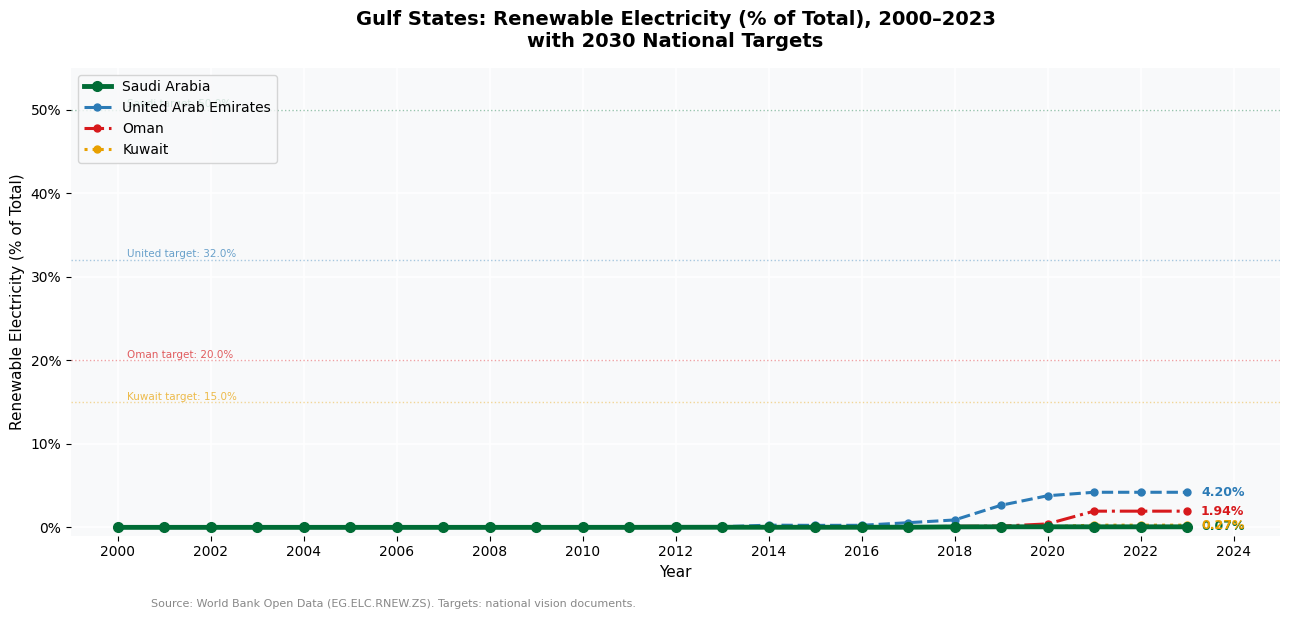

✅ Chart 1 saved


In [3]:
fig, ax = plt.subplots(figsize=(13, 6))

line_styles = ['-', '--', '-.', ':']

for i, country in enumerate(COUNTRIES):
    df_c = df_master[df_master['country_name'] == country].copy()
    lw   = 3.5 if country == 'Saudi Arabia' else 2.2
    ms   = 7   if country == 'Saudi Arabia' else 5
    zo   = 4   if country == 'Saudi Arabia' else 2

    ax.plot(
        df_c['year'],
        df_c['renewable_pct'],
        color     = COMP_COLORS[country],
        linewidth = lw,
        linestyle = line_styles[i],
        marker    = 'o',
        markersize= ms,
        zorder    = zo,
        label     = country
    )

    # End-of-line value label
    last = df_c[df_c['renewable_pct'].notna()]
    if not last.empty:
        ly = last['year'].max()
        lv = last[last['year'] == ly]['renewable_pct'].values[0]
        ax.text(ly + 0.3, lv, f'{lv:.2f}%',
                fontsize=9, fontweight='bold',
                color=COMP_COLORS[country], va='center')

# ── 2030 target reference lines ───────────────────────────────────────────────
for country, target in TARGET_2030.items():
    ax.axhline(y=target, color=COMP_COLORS[country],
               linestyle=':', linewidth=1, alpha=0.4)
    ax.text(2000.2, target + 0.3, f'{country.split()[0]} target: {target}%',
            fontsize=7.5, color=COMP_COLORS[country], alpha=0.7)

ax.set_title('Gulf States: Renewable Electricity (% of Total), 2000–2023\nwith 2030 National Targets', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Renewable Electricity (% of Total)')
ax.set_xlim(1999, 2025)
ax.set_ylim(-1, 55)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(fontsize=10, loc='upper left')

fig.text(0.12, -0.02,
         'Source: World Bank Open Data (EG.ELC.RNEW.ZS). Targets: national vision documents.',
         fontsize=8, color='#888888')

plt.tight_layout()
plt.savefig(VISUALS_DIR + 'chart1_renewable_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 1 saved')

### Chart 1 — Key Insight
> The UAE stands clearly ahead of peers with 4.2% renewable electricity — visible progress driven by Masdar City investments and the Barakah nuclear programme. Saudi Arabia, despite having the most ambitious 2030 target (50%), started from near-zero and remains there as of 2023. Kuwait and Oman show marginal movement. **Every country's current trajectory is nowhere near its 2030 target line.**

---
## Chart 2: Target vs. Reality — The Delivery Gap in One Picture

**Story:** The single most powerful chart in this project — shows each country's current position vs. its 2030 commitment.

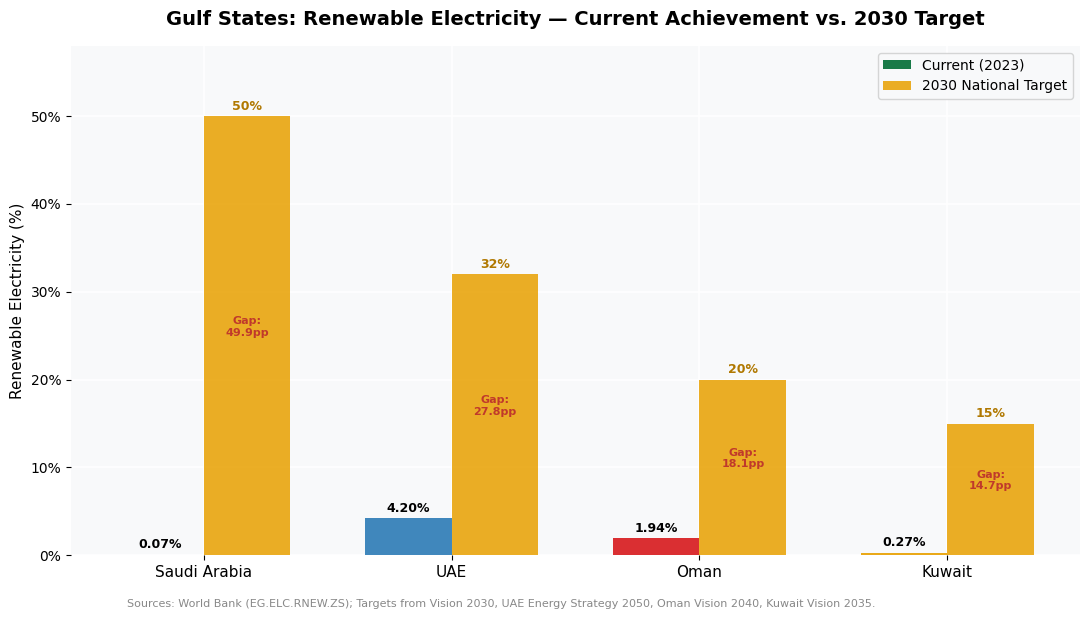

✅ Chart 2 saved

Delivery gap summary:
  Saudi Arabia            Current: 0.07%  Target: 50%  Gap: 49.9pp  Achieved: 0.1%
  UAE                     Current: 4.20%  Target: 32%  Gap: 27.8pp  Achieved: 13.1%
  Oman                    Current: 1.94%  Target: 20%  Gap: 18.1pp  Achieved: 9.7%
  Kuwait                  Current: 0.27%  Target: 15%  Gap: 14.7pp  Achieved: 1.8%


In [4]:
fig, ax = plt.subplots(figsize=(11, 6))

# ── Get latest renewable % per country ───────────────────────────────────────
latest_data = []
for country in COUNTRIES:
    df_c = df_master[(df_master['country_name'] == country) &
                     (df_master['renewable_pct'].notna())]
    if not df_c.empty:
        latest_year = df_c['year'].max()
        latest_val  = df_c[df_c['year'] == latest_year]['renewable_pct'].values[0]
        latest_data.append({
            'country' : country,
            'current' : latest_val,
            'target'  : TARGET_2030[country],
            'gap'     : TARGET_2030[country] - latest_val,
            'year'    : latest_year
        })

df_bar = pd.DataFrame(latest_data)
short_names = {
    'Saudi Arabia'         : 'Saudi Arabia',
    'United Arab Emirates' : 'UAE',
    'Oman'                 : 'Oman',
    'Kuwait'               : 'Kuwait'
}
df_bar['label'] = df_bar['country'].map(short_names)

x     = np.arange(len(df_bar))
width = 0.35

# ── Bars: current achievement ─────────────────────────────────────────────────
bars_current = ax.bar(
    x - width/2, df_bar['current'], width,
    color  = [COMP_COLORS[c] for c in df_bar['country']],
    label  = 'Current (2023)',
    zorder = 3,
    alpha  = 0.9
)

# ── Bars: 2030 target ─────────────────────────────────────────────────────────
bars_target = ax.bar(
    x + width/2, df_bar['target'], width,
    color  = COLORS['target'],
    label  = '2030 National Target',
    zorder = 3,
    alpha  = 0.85
)

# ── Value labels on bars ──────────────────────────────────────────────────────
for bar in bars_current:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.4,
            f'{h:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars_target:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.4,
            f'{h:.0f}%', ha='center', va='bottom', fontsize=9,
            fontweight='bold', color='#b07800')

# ── Gap annotations ───────────────────────────────────────────────────────────
for i, row in df_bar.iterrows():
    ax.annotate(
        f'Gap:\n{row["gap"]:.1f}pp',
        xy     = (x[i] + width/2, row['target']/2),
        fontsize = 8,
        ha     = 'center',
        color  = '#c0392b',
        fontweight = 'bold'
    )

ax.set_title('Gulf States: Renewable Electricity — Current Achievement vs. 2030 Target', pad=15)
ax.set_ylabel('Renewable Electricity (%)')
ax.set_xticks(x)
ax.set_xticklabels(df_bar['label'], fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(fontsize=10)
ax.set_ylim(0, 58)

fig.text(0.12, -0.02,
         'Sources: World Bank (EG.ELC.RNEW.ZS); Targets from Vision 2030, UAE Energy Strategy 2050, Oman Vision 2040, Kuwait Vision 2035.',
         fontsize=8, color='#888888')

plt.tight_layout()
plt.savefig(VISUALS_DIR + 'chart2_target_vs_reality.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 2 saved')
print()
print('Delivery gap summary:')
for _, row in df_bar.iterrows():
    pct = row['current'] / row['target'] * 100
    print(f"  {row['label']:22s}  Current: {row['current']:.2f}%  Target: {row['target']:.0f}%  "
          f"Gap: {row['gap']:.1f}pp  Achieved: {pct:.1f}%")

### Chart 2 — Key Insight
> **Saudi Arabia's gap is the most alarming in absolute terms** — 49.9 percentage points to close in 7 years, starting from near-zero. The UAE gap (27.8pp) is large but manageable given demonstrated momentum. Oman and Kuwait face smaller absolute gaps but their delivery pace must accelerate dramatically. **No Gulf state is currently on a trajectory to meet its 2030 target.**

---
## Chart 3: Saudi Arabia Deep-Dive — GDP vs. Renewable Growth

**Story:** Africa's largest oil economy vs. its clean energy delivery — the tension that defines Vision 2030.

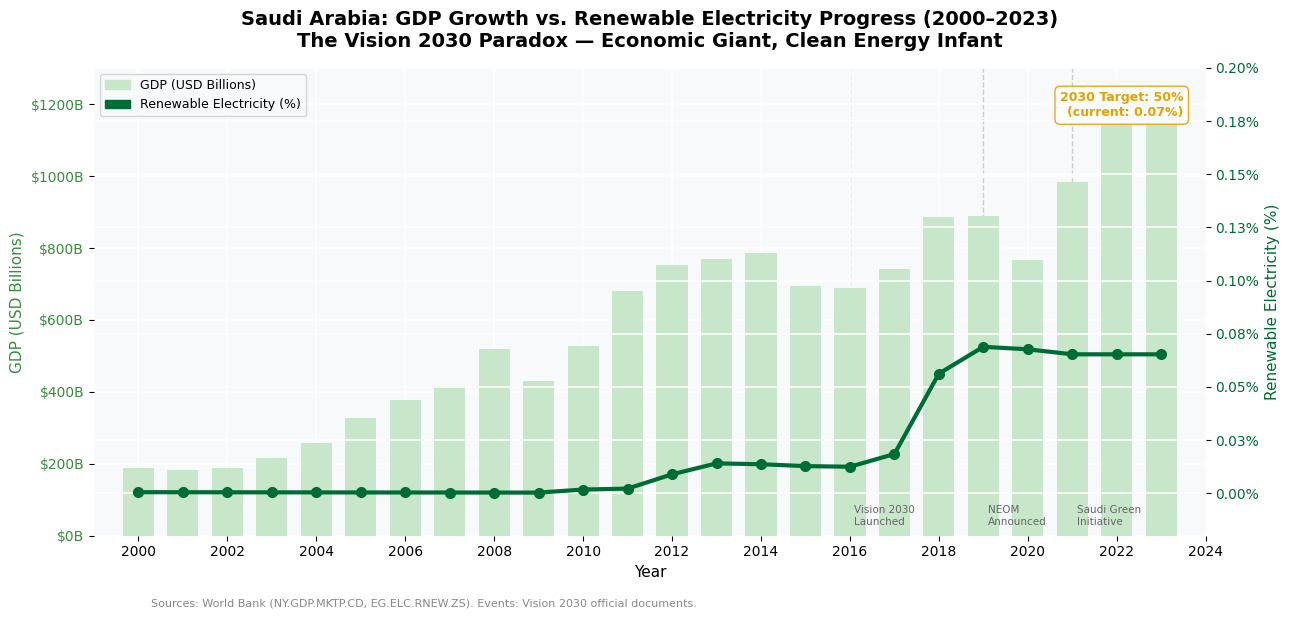

✅ Chart 3 saved


In [10]:
fig, ax1 = plt.subplots(figsize=(13, 6))

# ── Left axis: GDP in billions ────────────────────────────────────────────────
ax1.bar(
    df_saudi['year'],
    df_saudi['gdp_billion_usd'],
    color = '#c8e6c9',
    width = 0.7,
    zorder= 2,
    label = 'GDP (USD Billions)'
)
ax1.set_ylabel('GDP (USD Billions)', color='#388e3c', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#388e3c')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))

# ── Right axis: Renewable % ───────────────────────────────────────────────────
ax2 = ax1.twinx()
ax2.plot(
    df_saudi['year'],
    df_saudi['renewable_pct'],
    color     = COMP_COLORS['Saudi Arabia'],
    linewidth = 3,
    marker    = 'o',
    markersize= 7,
    zorder    = 4,
    label     = 'Renewable Electricity (%)'
)
ax2.set_ylabel('Renewable Electricity (%)', color=COMP_COLORS['Saudi Arabia'], fontsize=11)
ax2.tick_params(axis='y', labelcolor=COMP_COLORS['Saudi Arabia'])
ax2.set_ylim(-0.02, 0.20)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))

# ── Target label using axis coordinates (fixes the stretching bug) ────────────
ax2.text(0.98, 0.95,
         '2030 Target: 50%\n(current: 0.07%)',
         transform   = ax2.transAxes,
         ha='right', va='top',
         fontsize    = 9,
         color       = COLORS['target'],
         fontweight  = 'bold',
         bbox        = dict(boxstyle='round,pad=0.4', facecolor='white',
                            edgecolor=COLORS['target'], alpha=0.9))

# ── Annotate key policy events ────────────────────────────────────────────────
events = [
    (2016, 'Vision 2030\nLaunched'),
    (2019, 'NEOM\nAnnounced'),
    (2021, 'Saudi Green\nInitiative'),
]
for yr, label in events:
    ax1.axvline(x=yr, color='#cccccc', linestyle='--', linewidth=1, zorder=1)
    ax1.text(yr + 0.1, 30, label, fontsize=7.5, color='#666666')

# ── Legend ────────────────────────────────────────────────────────────────────
p1 = mpatches.Patch(color='#c8e6c9', label='GDP (USD Billions)')
p2 = mpatches.Patch(color=COMP_COLORS['Saudi Arabia'], label='Renewable Electricity (%)')
ax1.legend(handles=[p1, p2], loc='upper left', fontsize=9)

ax1.set_title('Saudi Arabia: GDP Growth vs. Renewable Electricity Progress (2000–2023)\n'
              'The Vision 2030 Paradox — Economic Giant, Clean Energy Infant', pad=15)
ax1.set_xlabel('Year')
ax1.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax1.set_xlim(1999, 2024)
ax1.spines['top'].set_visible(False)

fig.text(0.12, -0.02,
         'Sources: World Bank (NY.GDP.MKTP.CD, EG.ELC.RNEW.ZS). Events: Vision 2030 official documents.',
         fontsize=8, color='#888888')

plt.tight_layout()
plt.savefig(VISUALS_DIR + 'chart3_saudi_gdp_vs_renewable.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 3 saved')

### Chart 3 — Key Insight
> Saudi Arabia grew its GDP from under $200B in 2000 to over $1 trillion by 2022 — yet renewable electricity remained essentially flat at near-zero across the entire period. **Vision 2030 was announced in 2016, the Saudi Green Initiative in 2021 — but neither has yet produced measurable movement in the generation mix.** The 50% target by 2030 requires a complete transformation of the electricity sector in less than a decade from a standing start.

---
## Chart 4: CO₂ Per Capita Trend — Are Gulf Emissions Declining?

**Story:** Despite transition pledges, are emissions actually falling? This is the accountability chart.

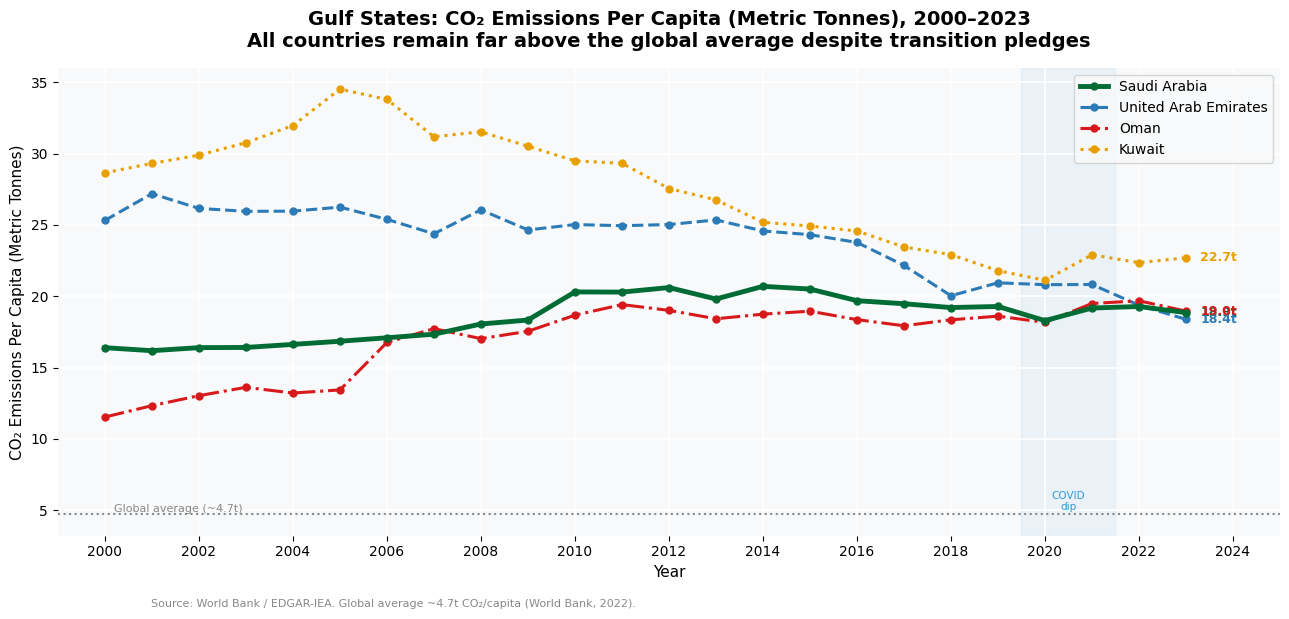

✅ Chart 4 saved


In [6]:
fig, ax = plt.subplots(figsize=(13, 6))

line_styles = ['-', '--', '-.', ':']

for i, country in enumerate(COUNTRIES):
    df_c = df_master[(df_master['country_name'] == country) &
                     (df_master['co2_per_capita'].notna())].copy()
    if df_c.empty:
        continue

    lw = 3.5 if country == 'Saudi Arabia' else 2.2
    zo = 4   if country == 'Saudi Arabia' else 2

    ax.plot(
        df_c['year'],
        df_c['co2_per_capita'],
        color     = COMP_COLORS[country],
        linewidth = lw,
        linestyle = line_styles[i],
        marker    = 'o',
        markersize= 5,
        zorder    = zo,
        label     = country
    )

    # End-of-line label
    last = df_c[df_c['year'] == df_c['year'].max()]
    if not last.empty:
        lv = last['co2_per_capita'].values[0]
        ax.text(last['year'].values[0] + 0.3, lv,
                f'{lv:.1f}t', fontsize=9, fontweight='bold',
                color=COMP_COLORS[country], va='center')

# ── Global average reference line ─────────────────────────────────────────────
ax.axhline(y=4.7, color='#888888', linestyle=':', linewidth=1.5)
ax.text(2000.2, 4.9, 'Global average (~4.7t)', fontsize=8, color='#888888')

# ── COVID dip annotation ──────────────────────────────────────────────────────
ax.axvspan(2019.5, 2021.5, alpha=0.07, color='#3498db')
ax.text(2020.5, 5, 'COVID\ndip', ha='center', fontsize=7.5, color='#3498db')

ax.set_title('Gulf States: CO₂ Emissions Per Capita (Metric Tonnes), 2000–2023\n'
             'All countries remain far above the global average despite transition pledges', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('CO₂ Emissions Per Capita (Metric Tonnes)')
ax.set_xlim(1999, 2025)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.legend(fontsize=10, loc='upper right')

fig.text(0.12, -0.02,
         'Source: World Bank / EDGAR-IEA. Global average ~4.7t CO₂/capita (World Bank, 2022).',
         fontsize=8, color='#888888')

plt.tight_layout()
plt.savefig(VISUALS_DIR + 'chart4_co2_per_capita.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 4 saved')

### Chart 4 — Key Insight
> All four Gulf states emit CO₂ per capita far above the global average. Kuwait consistently leads the group — confirmed by our revalidation exercise showing 23.7 tonnes per capita in 2024, the highest among the four countries studied. The COVID-19 dip of 2020 produced a temporary decline visible across all countries, but emissions rebounded by 2022. **Without meaningful renewable energy deployment, CO₂ trajectories will remain structurally elevated regardless of national pledges.**

---
## Chart 5: The 2030 Gap-to-Target Race

**Story:** Framing the challenge as a race — how far must each country travel in 7 years?

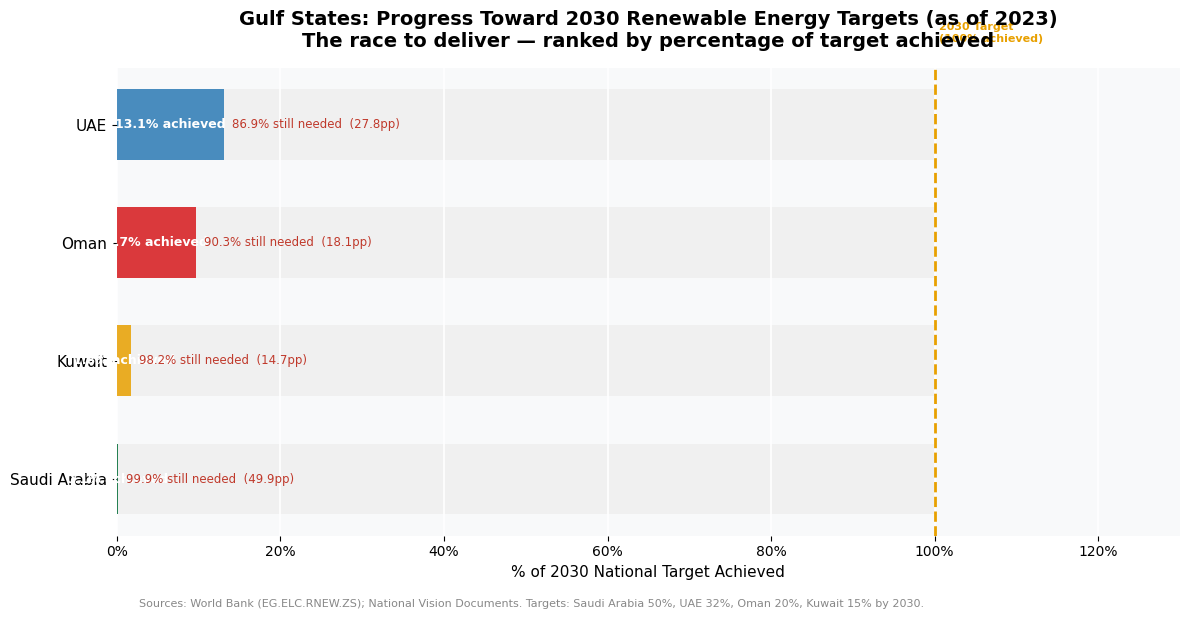

✅ Chart 5 saved


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

# ── Build progress data ───────────────────────────────────────────────────────
progress_data = []
for country in COUNTRIES:
    df_c = df_master[(df_master['country_name'] == country) &
                     (df_master['renewable_pct'].notna())]
    if not df_c.empty:
        latest = df_c[df_c['year'] == df_c['year'].max()].iloc[0]
        target = TARGET_2030[country]
        current = latest['renewable_pct']
        progress_data.append({
            'country' : country,
            'label'   : country.replace('United Arab Emirates', 'UAE'),
            'current' : current,
            'target'  : target,
            'achieved': current / target * 100,
            'remaining': (target - current) / target * 100
        })

df_prog = pd.DataFrame(progress_data)
df_prog = df_prog.sort_values('achieved', ascending=True)

y_pos = np.arange(len(df_prog))

# ── Horizontal bar — remaining gap (background) ───────────────────────────────
ax.barh(y_pos, 100,
        color='#f0f0f0', height=0.6, zorder=1)

# ── Horizontal bar — achieved portion ────────────────────────────────────────
for i, (_, row) in enumerate(df_prog.iterrows()):
    country = row['country']
    ax.barh(i, row['achieved'],
            color=COMP_COLORS[country], height=0.6,
            alpha=0.85, zorder=2)

    # Achieved % label inside bar
    ax.text(row['achieved'] / 2, i,
            f"{row['achieved']:.1f}% achieved",
            ha='center', va='center',
            fontsize=9, fontweight='bold', color='white', zorder=3)

    # Remaining gap label outside bar
    ax.text(row['achieved'] + 1, i,
            f"{row['remaining']:.1f}% still needed  ({row['target'] - row['current']:.1f}pp)",
            ha='left', va='center',
            fontsize=8.5, color='#c0392b', zorder=3)

# ── 100% marker line ──────────────────────────────────────────────────────────
ax.axvline(x=100, color='#E8A000', linewidth=2, linestyle='--', zorder=4)
ax.text(100.5, len(df_prog) - 0.3, '2030 Target\n(100% achieved)',
        fontsize=8, color='#E8A000', fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(df_prog['label'], fontsize=11)
ax.set_xlabel('% of 2030 National Target Achieved', fontsize=11)
ax.set_xlim(0, 130)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_title('Gulf States: Progress Toward 2030 Renewable Energy Targets (as of 2023)\n'
             'The race to deliver — ranked by percentage of target achieved', pad=15)
ax.grid(axis='x', color='white', linewidth=1.2)
ax.grid(axis='y', visible=False)

fig.text(0.12, -0.02,
         'Sources: World Bank (EG.ELC.RNEW.ZS); National Vision Documents. '
         'Targets: Saudi Arabia 50%, UAE 32%, Oman 20%, Kuwait 15% by 2030.',
         fontsize=8, color='#888888')

plt.tight_layout()
plt.savefig(VISUALS_DIR + 'chart5_gap_to_target_race.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 5 saved')

### Chart 5 — Key Insight
> The UAE leads the group having achieved 13.1% of its target — the only country with double-digit progress. Oman sits at 9.7%, Kuwait at 1.8%, and Saudi Arabia at just 0.1% of its 50% goal. **The race framing makes the challenge visceral: Saudi Arabia needs to travel 99.9% of its journey in 7 years.**

---
## Section 2: Analytical Summary & Consulting Recommendation

In [8]:
print('=' * 70)
print('ANALYTICAL SUMMARY — GULF RENEWABLE ENERGY TRANSITION (2000–2023)')
print('=' * 70)
print('''
FINDING 1 — No Gulf State Is On Track for Its 2030 Target
  UAE leads at 13.1% of target achieved (4.2% vs. 32% target)
  Oman sits at 9.7% (1.94% vs. 20% target)
  Kuwait at 1.8% (0.27% vs. 15% target)
  Saudi Arabia at 0.1% (0.07% vs. 50% target) — most alarming gap

FINDING 2 — Saudi Arabia's Gap Is Structurally Different
  GDP grew from ~$200B to ~$1T+ across the study period
  Renewable electricity remained near-zero throughout
  Vision 2030 (2016) and Saudi Green Initiative (2021) not yet
  reflected in actual generation mix data

FINDING 3 — CO₂ Emissions Remain Far Above Global Average
  Kuwait: highest per capita emitter (23.7t, World Bank 2024)
  Saudi Arabia, UAE, Oman: 18–19t vs. global average ~4.7t
  COVID dip (2020) was temporary — emissions rebounded by 2022
  Without renewable deployment, structural emissions will persist

FINDING 4 — Oman Is the Quiet Reform Model
  Most consistent delivery pace relative to target size
  Fiscal break-even reduced to $57/barrel (IMF 2025)
  Non-oil GDP at 73.3% — diversification most advanced in peer group
  Green hydrogen + Vision 2040 creating investment momentum
''')
print('=' * 70)
print('CONSULTING RECOMMENDATION')
print('=' * 70)
print('''
  For Saudi Arabia to meet its 50% renewable target by 2030,
  renewable electricity share must grow by approximately 7
  percentage points per year from 2024 — a pace never achieved
  by any Gulf state in the historical record.

  This is not an argument against the target. It is an argument
  for the scale of investment, regulatory reform, and grid
  infrastructure transformation required.

  Priority recommendations:
  1. Fast-track utility-scale solar PPAs — Al Shuaibah scale
     projects must become the norm, not the exception
  2. Grid modernisation investment — generation without
     transmission upgrades cannot reach consumers
  3. Localisation of renewable supply chain — Saudization
     of renewable workforce to sustain long-term delivery
  4. Carbon pricing signal — currently absent; needed to
     drive private sector investment at required scale
''')

ANALYTICAL SUMMARY — GULF RENEWABLE ENERGY TRANSITION (2000–2023)

FINDING 1 — No Gulf State Is On Track for Its 2030 Target
  UAE leads at 13.1% of target achieved (4.2% vs. 32% target)
  Oman sits at 9.7% (1.94% vs. 20% target)
  Kuwait at 1.8% (0.27% vs. 15% target)
  Saudi Arabia at 0.1% (0.07% vs. 50% target) — most alarming gap

FINDING 2 — Saudi Arabia's Gap Is Structurally Different
  GDP grew from ~$200B to ~$1T+ across the study period
  Renewable electricity remained near-zero throughout
  Vision 2030 (2016) and Saudi Green Initiative (2021) not yet
  reflected in actual generation mix data

FINDING 3 — CO₂ Emissions Remain Far Above Global Average
  Kuwait: highest per capita emitter (23.7t, World Bank 2024)
  Saudi Arabia, UAE, Oman: 18–19t vs. global average ~4.7t
  COVID dip (2020) was temporary — emissions rebounded by 2022
  Without renewable deployment, structural emissions will persist

FINDING 4 — Oman Is the Quiet Reform Model
  Most consistent delivery pace relati

---
## Section 3: Confirm All Charts Saved

In [9]:
print('Charts saved to visuals/ folder:')
print()
for f in sorted(os.listdir(VISUALS_DIR)):
    if f.endswith('.png'):
        size_kb = os.path.getsize(VISUALS_DIR + f) / 1024
        print(f'  ✅  {f:50s}  {size_kb:.0f} KB')

print()
print('Next step: Write README.md and push to GitHub as your second portfolio project.')

Charts saved to visuals/ folder:

  ✅  chart1_renewable_trajectory.png                     105 KB
  ✅  chart2_target_vs_reality.png                        83 KB
  ✅  chart3_saudi_gdp_vs_renewable.png                   635 KB
  ✅  chart4_co2_per_capita.png                           153 KB
  ✅  chart5_gap_to_target_race.png                       101 KB

Next step: Write README.md and push to GitHub as your second portfolio project.
